# SIRI-ET Compare
This Jupyter Notebook compares the data quality of DELFI SIRI-ET stream with the original communication logs of an ITCS of IVU. It requires two input files:
- `data/itcs.log` The communication logs of the IVU ITCS
- `data/siriet/*.xml` At least one recorded SIRI-ET dump of DELFI

## 1. Step: Extraction of ITCS Data
The ITCS log contains mixed text block logs and XML dumps of the VDV454-AUS data. The extraction block parses the XML contents and builds a dict in following structure:

```python
{
    'JourneyRef': [
        datetime(...),
        datetime(...),
        datetime(...),
        ...
    ]
}
```

This structure contains each journey and all timestamps, when data have been delivered for this journey.

In [1]:
from __future__ import annotations

from collections import defaultdict
from datetime import datetime
from typing import DefaultDict
from xml.etree import ElementTree as ET


# Result structure:
# {
#     "FahrtBezeichner": [datetime(...), datetime(...)]
# }
trip_timestamps: DefaultDict[str, list[datetime]] = defaultdict(list)


def process_xml(xml_text: str) -> None:
    """Extract timestamps and trip identifiers from a single XML block."""

    try:
        root: ET.Element = ET.fromstring(xml_text)
    except ET.ParseError:
        # Ignore malformed XML blocks
        return

    confirmation: ET.Element | None = root.find("./Bestaetigung")
    if confirmation is None:
        return

    timestamp_text: str | None = confirmation.attrib.get("Zst")
    if timestamp_text is None:
        return

    timestamp: datetime = datetime.fromisoformat(timestamp_text)

    # Only process IstFahrt elements.
    # SollFahrt elements are intentionally ignored.
    for istfahrt in root.iter("IstFahrt"):
        trip_identifier: ET.Element | None = istfahrt.find(
            "./FahrtRef/FahrtID/FahrtBezeichner"
        )

        if trip_identifier is None or not trip_identifier.text:
            continue

        trip_timestamps[trip_identifier.text.strip()].append(timestamp)


xml_lines: list[str] = []
collecting_xml: bool = False

with open("data/itcs.log", encoding="ISO-8859-1") as log_file:
    for line in log_file:
        xml_start: int = line.find("<?xml")

        # Start of a new XML block
        if xml_start >= 0:
            if xml_lines:
                process_xml("".join(xml_lines))

            xml_lines = [line[xml_start:]]
            collecting_xml = True
            continue

        if collecting_xml:
            # Detect the beginning of the next log entry
            is_log_line: bool = (
                len(line) >= 23
                and line[4] == "-"
                and line[7] == "-"
                and line[10] == " "
            )

            if is_log_line:
                process_xml("".join(xml_lines))
                xml_lines = []
                collecting_xml = False
            else:
                xml_lines.append(line)

# Process final XML block
if xml_lines:
    process_xml("".join(xml_lines))

# Ensure chronological ordering
for timestamps in trip_timestamps.values():
    timestamps.sort()

trip_timestamps = dict(trip_timestamps)

print(f"Number of unique trips: {len(trip_timestamps)}")
print(
    f"Number of timestamp records: "
    f"{sum(len(timestamps) for timestamps in trip_timestamps.values())}"
)

Number of unique trips: 759
Number of timestamp records: 7464


## 2. Step: Extraction of SIRI-ET Data
The SIRI-ET dumps contain a SIRI ServiceDelivery object. The extraction block parses the XMLs and extracts for each JourneyRef the RecordedAt timestamp into a structure like that:

```python
{
    'JourneyRef': {
        'response_timestamp': datetime(...),'
        'recorded_at': datetime(...)
    }        
    ...
}
```
The `recorded_at` is the timestamp when the message from the ITCS has arrived at the SIRI-ET broker. The `response_timestamp` represents the timestamp, when the updates became published in the SIRI-ET data.

As we're looking only at the realtime updates here, only those timestamps of trips which are currently really running are considered. Old journey which still are present in the SIRI-ET data are discarded.

In [2]:
from __future__ import annotations

from collections import defaultdict
from dataclasses import dataclass
from datetime import datetime, timedelta
from pathlib import Path
from typing import DefaultDict
from xml.etree.ElementTree import iterparse


@dataclass(slots=True)
class JourneyObservation:
    response_timestamp: datetime
    recorded_at: datetime


ACTIVE_JOURNEY_BUFFER = timedelta(minutes=1)


def parse_datetime(value: str) -> datetime:
    """Parse an ISO-8601 timestamp."""
    return datetime.fromisoformat(
        value.strip().replace("Z", "+00:00")
    )


def strip_namespace(tag: str) -> str:
    """Remove XML namespace from a tag name."""
    return tag.split("}", 1)[-1]


# --------------------------------------------------
# Result structure
# --------------------------------------------------
#
# {
#     VehicleJourneyRef: [
#         JourneyObservation(...),
#         JourneyObservation(...),
#     ]
# }
#
journey_observations: DefaultDict[
    str,
    list[JourneyObservation],
] = defaultdict(list)


# --------------------------------------------------
# Analysis metadata
# --------------------------------------------------

analysis_start: datetime | None = None
analysis_end: datetime | None = None


# --------------------------------------------------
# Collect files
# --------------------------------------------------

siriet_directory = Path("data/siriet")

xml_files = sorted(
    file
    for file in siriet_directory.iterdir()
    if file.is_file()
)

total_files = len(xml_files)
num_siri_files = total_files

print(
    f"Found {total_files:,} SIRI-ET files to process."
)


# --------------------------------------------------
# Parse all SIRI snapshots
# --------------------------------------------------

for current_file_index, xml_file in enumerate(
    xml_files,
    start=1,
):

    if (
        current_file_index == 1
        or current_file_index % 100 == 0
        or current_file_index == total_files
    ):
        progress = (
            current_file_index
            / total_files
            * 100
        )

        print(
            f"Processed "
            f"{current_file_index:,}/{total_files:,} files "
            f"({progress:.1f}%)"
        )

    response_timestamp: datetime | None = None

    for _, element in iterparse(
        xml_file,
        events=("end",),
    ):
        tag = strip_namespace(element.tag)

        # --------------------------------------------------
        # File-level ResponseTimestamp
        # --------------------------------------------------

        if (
            response_timestamp is None
            and tag == "ResponseTimestamp"
            and element.text
        ):
            response_timestamp = parse_datetime(
                element.text
            )

            if analysis_start is None:
                analysis_start = response_timestamp
            else:
                analysis_start = min(
                    analysis_start,
                    response_timestamp,
                )

            if analysis_end is None:
                analysis_end = response_timestamp
            else:
                analysis_end = max(
                    analysis_end,
                    response_timestamp,
                )

        # --------------------------------------------------
        # EstimatedVehicleJourney
        # --------------------------------------------------

        if tag != "EstimatedVehicleJourney":
            continue

        recorded_at: datetime | None = None
        vehicle_journey_ref: str | None = None

        departure_candidates: list[datetime] = []
        arrival_candidates: list[datetime] = []

        for child in element.iter():

            child_tag = strip_namespace(
                child.tag
            )

            # ----------------------------------------------
            # Observation timestamp
            # ----------------------------------------------

            if (
                child_tag == "RecordedAtTime"
                and child.text
                and recorded_at is None
            ):
                recorded_at = parse_datetime(
                    child.text
                )

            # ----------------------------------------------
            # Journey identifier
            # ----------------------------------------------

            elif (
                child_tag == "VehicleJourneyRef"
                and child.text
            ):
                vehicle_journey_ref = (
                    child.text.strip()
                )

            # ----------------------------------------------
            # Journey timing
            # ----------------------------------------------

            elif (
                child_tag == "EstimatedDepartureTime"
                and child.text
            ):
                departure_candidates.append(
                    parse_datetime(child.text)
                )

            elif (
                child_tag == "AimedDepartureTime"
                and child.text
            ):
                departure_candidates.append(
                    parse_datetime(child.text)
                )

            elif (
                child_tag == "EstimatedArrivalTime"
                and child.text
            ):
                arrival_candidates.append(
                    parse_datetime(child.text)
                )

            elif (
                child_tag == "AimedArrivalTime"
                and child.text
            ):
                arrival_candidates.append(
                    parse_datetime(child.text)
                )

        # --------------------------------------------------
        # Basic validation
        # --------------------------------------------------

        if (
            response_timestamp is None
            or recorded_at is None
            or vehicle_journey_ref is None
        ):
            element.clear()
            continue

        if not departure_candidates:
            element.clear()
            continue

        journey_start = min(
            departure_candidates
        )

        # Prefer arrivals for end time.
        # If no arrival exists, use the last departure.
        if arrival_candidates:
            journey_end = max(
                arrival_candidates
            )
        else:
            journey_end = max(
                departure_candidates
            )

        # --------------------------------------------------
        # Keep only observations that were taken while
        # the journey was actually active.
        # --------------------------------------------------

        if not (
            journey_start - ACTIVE_JOURNEY_BUFFER
            <= response_timestamp
            <= journey_end + ACTIVE_JOURNEY_BUFFER
        ):
            element.clear()
            continue

        journey_observations[
            vehicle_journey_ref
        ].append(
            JourneyObservation(
                response_timestamp=response_timestamp,
                recorded_at=recorded_at,
            )
        )

        # Release memory while streaming
        element.clear()


# --------------------------------------------------
# Validate analysis window
# --------------------------------------------------

if (
    analysis_start is None
    or analysis_end is None
):
    raise RuntimeError(
        "No valid ResponseTimestamp found in SIRI files."
    )


# --------------------------------------------------
# Sort observations chronologically
# --------------------------------------------------

for observations in journey_observations.values():

    observations.sort(
        key=lambda observation:
        observation.response_timestamp
    )


journey_observations = dict(
    journey_observations
)


# --------------------------------------------------
# Existing ITCS matching functionality
# --------------------------------------------------

matched_itcs_journeys: set[str] = set()

for siri_journey in journey_observations:

    for itcs_journey in trip_timestamps:

        if siri_journey.startswith(
            itcs_journey
        ):
            matched_itcs_journeys.add(
                itcs_journey
            )
            break


# --------------------------------------------------
# Statistics
# --------------------------------------------------

print()

print(
    f"Analysis window: "
    f"{analysis_start.isoformat()} "
    f"to "
    f"{analysis_end.isoformat()}"
)

print(
    f"Number of SIRI snapshots: "
    f"{num_siri_files:,}"
)

print(
    f"Number of unique SIRI journeys: "
    f"{len(journey_observations):,}"
)

print(
    f"Number of journeys from ITCS: "
    f"{len(matched_itcs_journeys):,}"
)

print(
    f"Number of observations: "
    f"{sum(len(v) for v in journey_observations.values()):,}"
)

Found 486 SIRI-ET files to process.
Processed 1/486 files (0.2%)
Processed 100/486 files (20.6%)
Processed 200/486 files (41.2%)
Processed 300/486 files (61.7%)
Processed 400/486 files (82.3%)
Processed 486/486 files (100.0%)

Analysis window: 2026-06-13T07:49:59.042000+00:00 to 2026-06-13T15:58:06.335000+00:00
Number of SIRI snapshots: 486
Number of unique SIRI journeys: 15,865
Number of journeys from ITCS: 498
Number of observations: 444,306


## 3. Step: Metrics
Out of the collected data, following metrics are built:
- Assimilation Latency: This is the time which an ITCS update takes to be recorded by the SIRI-ET sink. It is **not** the time when the update becomes visible!
- Event Propagation Latency: This is the time range which an ITCS updates takes to be exposed in SIRI-ET data.
- Snapshot Staleness: This is the 'age of the data' in a SIRI-ET snapshot.
- Future ITCS Updates: This is the number of updates the ITCS has sent after the last publication of a journey.


---- SUMMARY ----
Matched observations: 12606

Assimilation Latency
Mean    : 3.168 s
StdDev  : 0.146 s
Max     : 3.821 s
P50     : 3.136 s
P60     : 3.165 s
P70     : 3.196 s
P80     : 3.254 s
P90     : 3.384 s
P95     : 3.485 s
P99     : 3.593 s
Samples : 12606

Event Propagation Latency (ITCS → SIRI Visibility)
Mean    : 1139.521 s
StdDev  : 1977.900 s
Max     : 11149.042 s
P50     : 230.999 s
P60     : 291.435 s
P70     : 598.509 s
P80     : 1737.803 s
P90     : 3930.068 s
P95     : 7189.251 s
P99     : 7385.531 s
Samples : 169345

Snapshot Staleness
Mean    : 1365.235 s
StdDev  : 2509.331 s
Max     : 10223.396 s
P50     : 229.417 s
P60     : 326.443 s
P70     : 512.028 s
P80     : 1127.194 s
P90     : 7203.185 s
P95     : 7446.132 s
P99     : 8184.598 s
Samples : 12606

---- FUTURE ITCS UPDATES ----
Mean : 5.856
Max  : 47


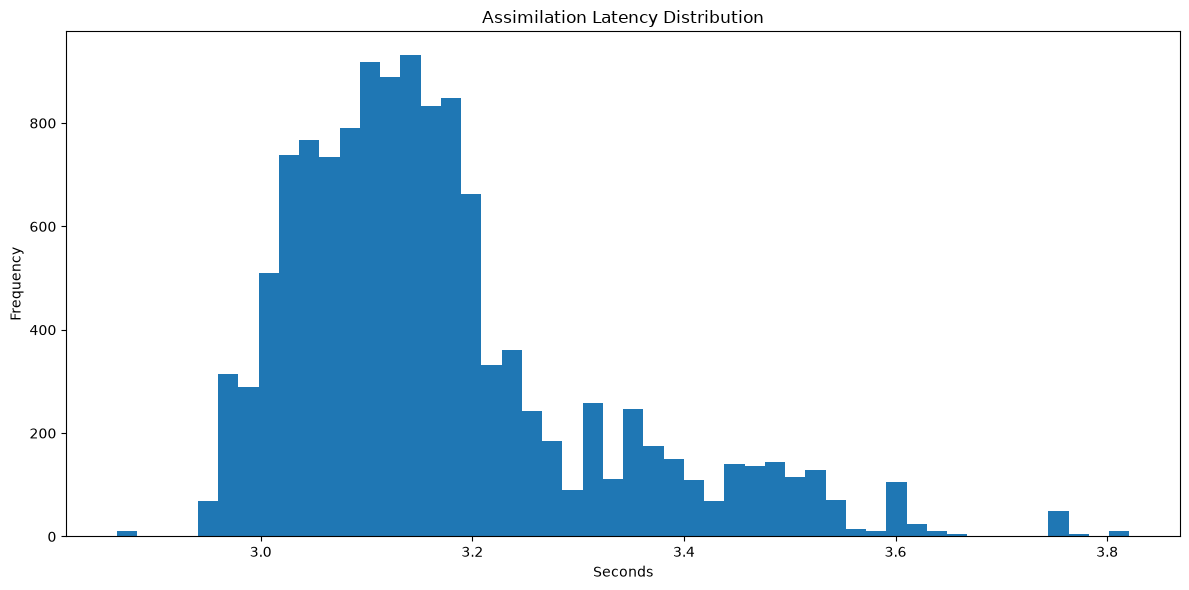

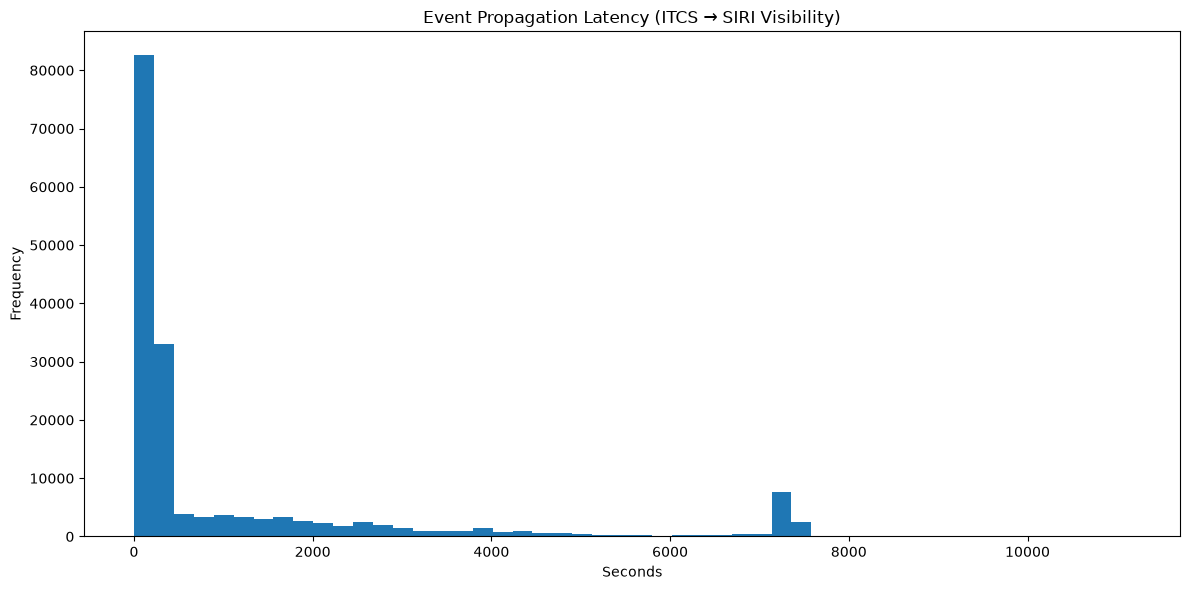

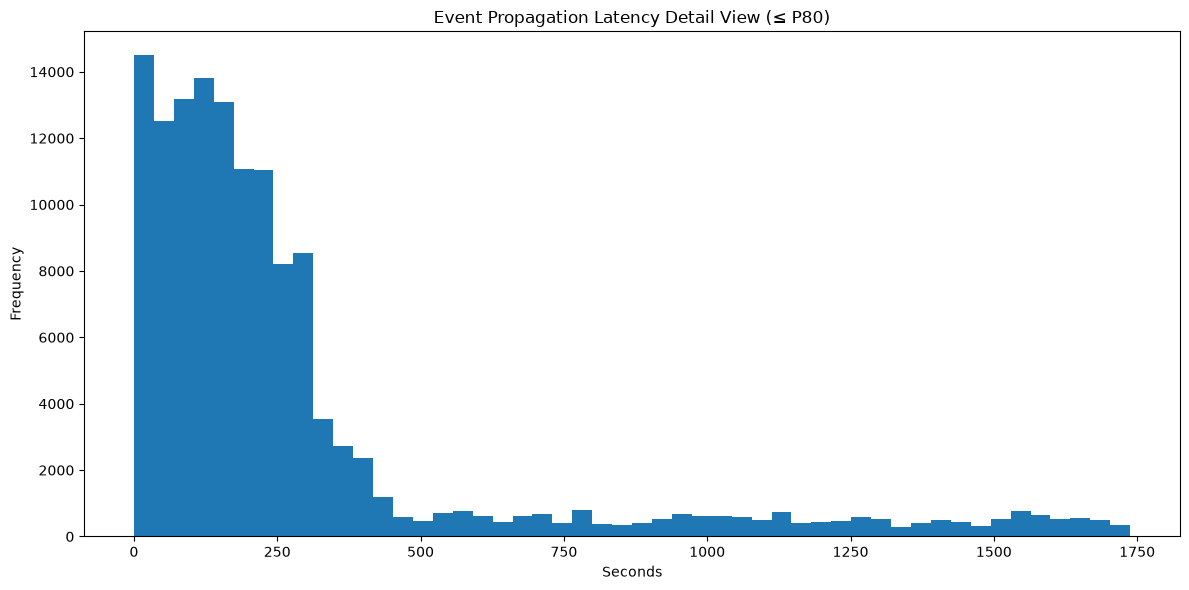

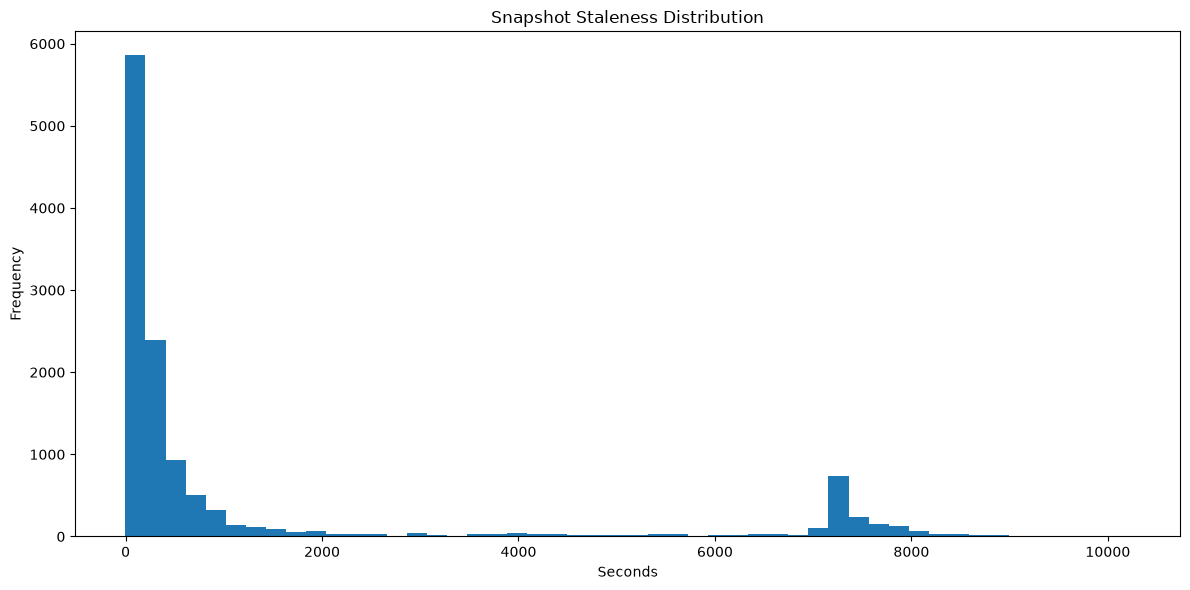

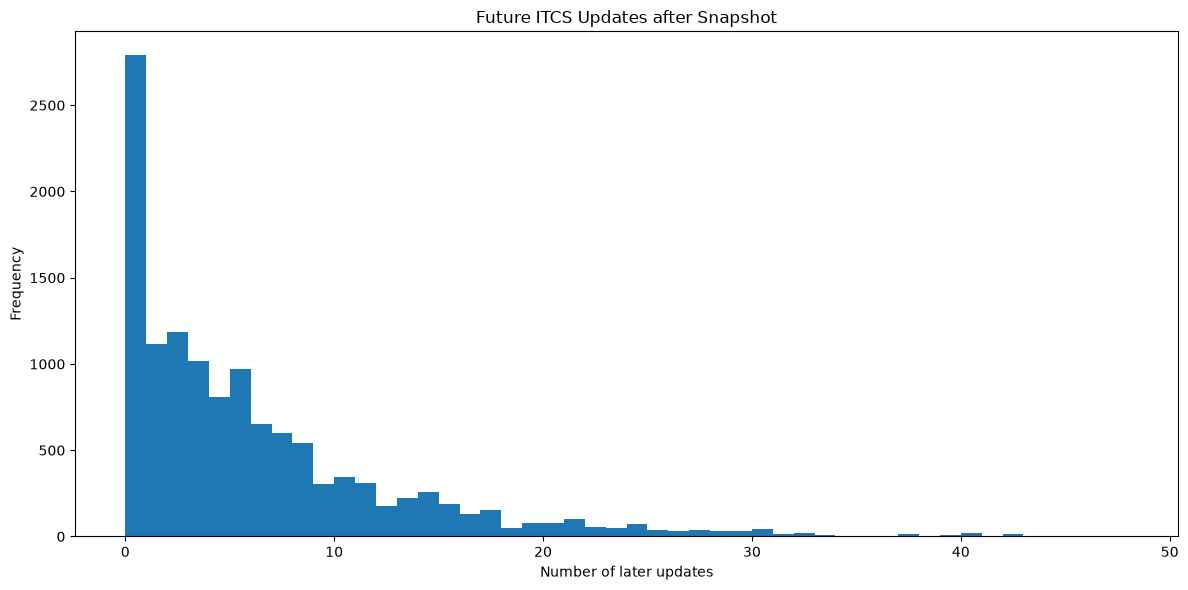

In [13]:
from __future__ import annotations

from statistics import mean, stdev
from typing import List, Optional

import matplotlib.pyplot as plt


# --------------------------------------------------
# Inputs
# --------------------------------------------------
# trip_timestamps: dict[str, list[datetime]]
# journey_observations: dict[str, list[JourneyObservation]]
# --------------------------------------------------


assimilation_latency_seconds: List[float] = []
event_propagation_latency_seconds: List[float] = []
snapshot_staleness_seconds: List[float] = []
updates_after_snapshot: List[int] = []

matched_observations: int = 0


# --------------------------------------------------
# Percentile (robust linear interpolation)
# --------------------------------------------------

def percentile(
    values: list[float],
    p: float,
) -> float:

    if not values:
        return 0.0

    vals = sorted(values)

    if len(vals) == 1:
        return vals[0]

    idx = (len(vals) - 1) * p

    lo = int(idx)
    hi = min(lo + 1, len(vals) - 1)

    weight = idx - lo

    return vals[lo] + (
        (vals[hi] - vals[lo]) * weight
    )


# --------------------------------------------------
# Statistics helper
# --------------------------------------------------

def compute_stats(
    values: list[float],
) -> dict[str, float]:

    if not values:
        return {
            "mean": 0.0,
            "stddev": 0.0,
            "max": 0.0,
            "p50": 0.0,
            "p60": 0.0,
            "p70": 0.0,
            "p80": 0.0,
            "p90": 0.0,
            "p95": 0.0,
            "p99": 0.0,
        }

    return {
        "mean": mean(values),
        "stddev": (
            stdev(values)
            if len(values) > 1
            else 0.0
        ),
        "max": max(values),

        "p50": percentile(values, 0.50),
        "p60": percentile(values, 0.60),
        "p70": percentile(values, 0.70),
        "p80": percentile(values, 0.80),
        "p90": percentile(values, 0.90),
        "p95": percentile(values, 0.95),
        "p99": percentile(values, 0.99),
    }


# --------------------------------------------------
# Core computation
# --------------------------------------------------

for siri_journey, observations in journey_observations.items():

    matching_itcs_journey: Optional[str] = next(
        (
            itcs_journey
            for itcs_journey in trip_timestamps
            if siri_journey.startswith(
                itcs_journey
            )
        ),
        None,
    )

    if matching_itcs_journey is None:
        continue

    itcs_updates = trip_timestamps[
        matching_itcs_journey
    ]

    for observation in observations:

        matched_observations += 1

        # --------------------------------------------------
        # 1. Assimilation Latency
        #
        # RecordedAtTime
        # minus
        # latest ITCS update before RecordedAtTime
        # --------------------------------------------------

        latest_itcs_before_recorded = max(
            (
                timestamp
                for timestamp in itcs_updates
                if timestamp <= observation.recorded_at
            ),
            default=None,
        )

        if latest_itcs_before_recorded:

            assimilation_latency_seconds.append(
                (
                    observation.recorded_at
                    - latest_itcs_before_recorded
                ).total_seconds()
            )

        # --------------------------------------------------
        # 2. Event Propagation Latency
        #
        # First SIRI snapshot that exposes
        # an ITCS update.
        # --------------------------------------------------

        for itcs_timestamp in itcs_updates:

            first_siri_after_itcs = next(
                (
                    obs.response_timestamp
                    for obs in observations
                    if obs.response_timestamp
                    >= itcs_timestamp
                ),
                None,
            )

            if first_siri_after_itcs:

                event_propagation_latency_seconds.append(
                    (
                        first_siri_after_itcs
                        - itcs_timestamp
                    ).total_seconds()
                )

        # --------------------------------------------------
        # 3. Snapshot Staleness
        #
        # ResponseTimestamp
        # minus
        # RecordedAtTime
        # --------------------------------------------------

        snapshot_staleness_seconds.append(
            (
                observation.response_timestamp
                - observation.recorded_at
            ).total_seconds()
        )

        # --------------------------------------------------
        # 4. Future ITCS updates
        # --------------------------------------------------

        updates_after_snapshot.append(
            sum(
                1
                for timestamp in itcs_updates
                if timestamp >
                observation.response_timestamp
            )
        )


# --------------------------------------------------
# Sorting
# --------------------------------------------------

assimilation_latency_seconds.sort()

event_propagation_latency_seconds.sort()

snapshot_staleness_seconds.sort()


# --------------------------------------------------
# Detail View Threshold
# --------------------------------------------------

event_propagation_p80 = percentile(
    event_propagation_latency_seconds,
    0.80,
)


# --------------------------------------------------
# Pretty printing
# --------------------------------------------------

def print_metric(
    name: str,
    values: list[float],
) -> None:

    stats = compute_stats(values)

    print()
    print("=" * 70)
    print(name)
    print("=" * 70)

    print(
        f"Mean    : {stats['mean']:.3f} s"
    )

    print(
        f"StdDev  : {stats['stddev']:.3f} s"
    )

    print(
        f"Max     : {stats['max']:.3f} s"
    )

    print(
        f"P50     : {stats['p50']:.3f} s"
    )

    print(
        f"P60     : {stats['p60']:.3f} s"
    )

    print(
        f"P70     : {stats['p70']:.3f} s"
    )

    print(
        f"P80     : {stats['p80']:.3f} s"
    )

    print(
        f"P90     : {stats['p90']:.3f} s"
    )

    print(
        f"P95     : {stats['p95']:.3f} s"
    )

    print(
        f"P99     : {stats['p99']:.3f} s"
    )

    print(
        f"Samples : {len(values)}"
    )


# --------------------------------------------------
# Console Output
# --------------------------------------------------

print()
print("---- SUMMARY ----")
print(
    f"Matched observations: "
    f"{matched_observations}"
)

print_metric(
    "Assimilation Latency",
    assimilation_latency_seconds,
)

print_metric(
    "Event Propagation Latency (ITCS → SIRI Visibility)",
    event_propagation_latency_seconds,
)

print_metric(
    "Snapshot Staleness",
    snapshot_staleness_seconds,
)

print()
print("---- FUTURE ITCS UPDATES ----")

print(
    f"Mean : "
    f"{mean(updates_after_snapshot) if updates_after_snapshot else 0:.3f}"
)

print(
    f"Max  : "
    f"{max(updates_after_snapshot) if updates_after_snapshot else 0}"
)


# --------------------------------------------------
# Plot 1
# Assimilation Latency
# --------------------------------------------------

plt.figure(figsize=(12, 6))

plt.hist(
    assimilation_latency_seconds,
    bins=50,
)

plt.title(
    "Assimilation Latency Distribution"
)

plt.xlabel(
    "Seconds"
)

plt.ylabel(
    "Frequency"
)

plt.tight_layout()
plt.show()


# --------------------------------------------------
# Plot 2
# Event Propagation Latency
# --------------------------------------------------

plt.figure(figsize=(12, 6))

plt.hist(
    event_propagation_latency_seconds,
    bins=50,
)

plt.title(
    "Event Propagation Latency (ITCS → SIRI Visibility)"
)

plt.xlabel(
    "Seconds"
)

plt.ylabel(
    "Frequency"
)

plt.tight_layout()
plt.show()


# --------------------------------------------------
# Plot 2b
# Event Propagation Latency Detail View
# (without upper 20 % tail)
# --------------------------------------------------

event_propagation_detail = [
    value
    for value in event_propagation_latency_seconds
    if value <= event_propagation_p80
]

plt.figure(figsize=(12, 6))

plt.hist(
    event_propagation_detail,
    bins=50,
)

plt.title(
    "Event Propagation Latency Detail View (≤ P80)"
)

plt.xlabel(
    "Seconds"
)

plt.ylabel(
    "Frequency"
)

plt.tight_layout()
plt.show()


# --------------------------------------------------
# Plot 3
# Snapshot Staleness
# --------------------------------------------------

plt.figure(figsize=(12, 6))

plt.hist(
    snapshot_staleness_seconds,
    bins=50,
)

plt.title(
    "Snapshot Staleness Distribution"
)

plt.xlabel(
    "Seconds"
)

plt.ylabel(
    "Frequency"
)

plt.tight_layout()
plt.show()


# --------------------------------------------------
# Plot 4
# Future ITCS Updates
# --------------------------------------------------

plt.figure(figsize=(12, 6))

plt.hist(
    updates_after_snapshot,
    bins=range(
        0,
        (
            max(updates_after_snapshot) + 2
            if updates_after_snapshot
            else 1
        ),
    ),
)

plt.title(
    "Future ITCS Updates after Snapshot"
)

plt.xlabel(
    "Number of later updates"
)

plt.ylabel(
    "Frequency"
)

plt.tight_layout()
plt.show()

In [16]:
from __future__ import annotations

from pathlib import Path
from datetime import datetime
from statistics import mean, stdev

import matplotlib.pyplot as plt


# --------------------------------------------------
# Path helper
# --------------------------------------------------

def to_md_path(path: str) -> str:
    return Path(path).as_posix()


# --------------------------------------------------
# Percentile
# --------------------------------------------------

def percentile(
    values: list[float],
    p: float,
) -> float:

    if not values:
        return 0.0

    values = sorted(values)

    if len(values) == 1:
        return values[0]

    index = (len(values) - 1) * p

    lower = int(index)
    upper = min(lower + 1, len(values) - 1)

    weight = index - lower

    return (
        values[lower]
        + (values[upper] - values[lower]) * weight
    )


# --------------------------------------------------
# Statistics helper
# --------------------------------------------------

def safe_stats(
    values: list[float],
) -> dict[str, float]:

    if not values:
        return {
            "count": 0,
            "mean": 0.0,
            "stddev": 0.0,
            "max": 0.0,
            "p50": 0.0,
            "p60": 0.0,
            "p70": 0.0,
            "p80": 0.0,
            "p90": 0.0,
            "p95": 0.0,
            "p99": 0.0,
        }

    return {
        "count": len(values),
        "mean": mean(values),
        "stddev": (
            stdev(values)
            if len(values) > 1
            else 0.0
        ),
        "max": max(values),

        "p50": percentile(values, 0.50),
        "p60": percentile(values, 0.60),
        "p70": percentile(values, 0.70),
        "p80": percentile(values, 0.80),
        "p90": percentile(values, 0.90),
        "p95": percentile(values, 0.95),
        "p99": percentile(values, 0.99),
    }


# --------------------------------------------------
# Plot helper
# --------------------------------------------------

def save_histogram(
    data: list[float],
    title: str,
    filename: str,
    xlabel: str,
) -> str:

    output_dir = Path("results")
    output_dir.mkdir(exist_ok=True)

    output_path = output_dir / filename

    plt.figure(figsize=(10, 5))

    plt.hist(
        data,
        bins=50,
    )

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Frequency")

    plt.tight_layout()

    plt.savefig(
        output_path,
        dpi=150,
    )

    plt.close()

    return str(output_path)


# --------------------------------------------------
# Plot generation
# --------------------------------------------------

assimilation_plot = save_histogram(
    assimilation_latency_seconds,
    "Assimilation Latency Distribution",
    "assimilation_latency.png",
    "Seconds",
)

event_propagation_plot = save_histogram(
    event_propagation_latency_seconds,
    "Event Propagation Latency Distribution",
    "event_propagation_latency.png",
    "Seconds",
)

event_propagation_plot_p80 = save_histogram(
    event_propagation_detail,
    "Event Propagation Latency Detail View (≤ P80)",
    "event_propagation_latency_detail.png",
    "Seconds",
)

staleness_plot = save_histogram(
    snapshot_staleness_seconds,
    "Snapshot Staleness Distribution",
    "snapshot_staleness.png",
    "Seconds",
)

updates_plot = save_histogram(
    updates_after_snapshot,
    "Future ITCS Updates",
    "updates_after_snapshot.png",
    "Number of updates",
)


# --------------------------------------------------
# Metadata
# --------------------------------------------------

start_time = analysis_start.isoformat()
end_time = analysis_end.isoformat()

num_snapshots = num_siri_files

num_observations = sum(
    len(v)
    for v in journey_observations.values()
)

timestamp = datetime.utcnow().strftime(
    "%Y-%m-%d %H:%M:%S UTC"
)


# --------------------------------------------------
# Statistics
# --------------------------------------------------

assimilation_stats = safe_stats(
    assimilation_latency_seconds
)

event_propagation_stats = safe_stats(
    event_propagation_latency_seconds
)

staleness_stats = safe_stats(
    snapshot_staleness_seconds
)

updates_mean = (
    mean(updates_after_snapshot)
    if updates_after_snapshot
    else 0.0
)

updates_max = (
    max(updates_after_snapshot)
    if updates_after_snapshot
    else 0
)


# --------------------------------------------------
# Markdown builder
# --------------------------------------------------

lines: list[str] = []

lines.append(
    "# SIRI / ITCS Temporal Analysis Report"
)
lines.append("")

lines.append(
    f"Generated: {timestamp}"
)
lines.append("")


# --------------------------------------------------
# Scope
# --------------------------------------------------

lines.append(
    "## 1. Study Design and Data Scope"
)

lines.append(
    "This report evaluates temporal characteristics of real-time public transport information flows between an ITCS source system and SIRI-ET snapshots."
)

lines.append("")

lines.append(
    f"Observation window: {start_time} → {end_time}"
)

lines.append(
    f"Number of SIRI snapshots analysed: {num_snapshots}"
)

lines.append(
    f"Number of journey observations analysed: {num_observations}"
)

lines.append("")


# --------------------------------------------------
# Section helper
# --------------------------------------------------

def add_metric_section(
    title: str,
    description: str,
    stats: dict[str, float],
    plot_path: str,
    plot_path2: str | None = None
) -> None:

    lines.append(f"## {title}")
    lines.append("")
    lines.append(description)
    lines.append("")

    lines.append(
        "### Statistical Summary"
    )

    lines.append(
        f"- Sample Count: {stats['count']}"
    )

    lines.append(
        f"- Mean: {stats['mean']:.3f} s"
    )

    lines.append(
        f"- Standard Deviation: {stats['stddev']:.3f} s"
    )

    lines.append(
        f"- Maximum: {stats['max']:.3f} s"
    )

    lines.append("")

    lines.append(
        "### Quantiles"
    )

    lines.append(
        f"- P50: {stats['p50']:.3f} s"
    )
    lines.append(
        f"- P60: {stats['p60']:.3f} s"
    )
    lines.append(
        f"- P70: {stats['p70']:.3f} s"
    )
    lines.append(
        f"- P80: {stats['p80']:.3f} s"
    )
    lines.append(
        f"- P90: {stats['p90']:.3f} s"
    )
    lines.append(
        f"- P95: {stats['p95']:.3f} s"
    )
    lines.append(
        f"- P99: {stats['p99']:.3f} s"
    )

    lines.append("")

    lines.append(
        "### Distribution"
    )

    lines.append(
        f"![{title}]({to_md_path(plot_path)})"
    )

    if plot_path2 is not None:
        lines.append(
            f"![{title}]({to_md_path(plot_path2)})"
        )

    lines.append("")


# --------------------------------------------------
# Metrics
# --------------------------------------------------

add_metric_section(
    "2. Assimilation Latency",
    (
        "Assimilation latency measures the temporal distance between "
        "the latest ITCS update and the corresponding SIRI "
        "RecordedAtTime timestamp. It approximates internal processing "
        "and data ingestion latency within the ET generation chain."
    ),
    assimilation_stats,
    assimilation_plot,
)

add_metric_section(
    "3. Event Propagation Latency",
    (
        "Event propagation latency measures the delay between an ITCS "
        "event occurrence and the first SIRI snapshot in which that "
        "event becomes externally visible. This metric represents the "
        "effective end-to-end propagation delay experienced by consumers."
    ),
    event_propagation_stats,
    event_propagation_plot,
    event_propagation_plot_p80,
)

add_metric_section(
    "4. Snapshot Staleness",
    (
        "Snapshot staleness quantifies the age of information at the "
        "moment of publication. It is calculated as the difference "
        "between ResponseTimestamp and RecordedAtTime."
    ),
    staleness_stats,
    staleness_plot,
)


# --------------------------------------------------
# ITCS update activity
# --------------------------------------------------

lines.append(
    "## 5. Post-Snapshot ITCS Update Activity"
)

lines.append("")

lines.append(
    "This metric quantifies how many ITCS updates occurred after a "
    "snapshot was published. High values indicate that additional "
    "state changes became available shortly after publication."
)

lines.append("")

lines.append(
    f"- Mean number of updates: {updates_mean:.3f}"
)

lines.append(
    f"- Maximum number of updates: {updates_max}"
)

lines.append("")

lines.append(
    f"![Future Updates]({to_md_path(updates_plot)})"
)

lines.append("")


# --------------------------------------------------
# Interpretation
# --------------------------------------------------

lines.append(
    "## 6. Interpretation"
)

lines.append("")

lines.append(
    "The presented metrics separate different stages of temporal behaviour "
    "within the real-time information pipeline."
)

lines.append("")

lines.append(
    "- Assimilation latency characterises ingestion and processing delays."
)

lines.append(
    "- Event propagation latency characterises externally observable responsiveness."
)

lines.append(
    "- Snapshot staleness characterises information freshness at publication time."
)

lines.append(
    "- Post-snapshot update activity characterises remaining system dynamics after dissemination."
)

lines.append("")

lines.append(
    "Together, these measures provide a decomposition of real-time system behaviour "
    "that can be used to identify bottlenecks and evaluate service quality."
)

lines.append("")


# --------------------------------------------------
# Appendix
# --------------------------------------------------

lines.append(
    "## Appendix A: Complete Quantile Summary"
)

lines.append("")

for name, stats in [

    (
        "Assimilation Latency",
        assimilation_stats,
    ),

    (
        "Event Propagation Latency",
        event_propagation_stats,
    ),

    (
        "Snapshot Staleness",
        staleness_stats,
    ),

]:
    lines.append(
        f"### {name}"
    )

    lines.append(
        f"- Sample Count: {stats['count']}"
    )

    lines.append(
        f"- Mean: {stats['mean']:.3f}"
    )

    lines.append(
        f"- StdDev: {stats['stddev']:.3f}"
    )

    lines.append(
        f"- P50: {stats['p50']:.3f}"
    )

    lines.append(
        f"- P60: {stats['p60']:.3f}"
    )

    lines.append(
        f"- P70: {stats['p70']:.3f}"
    )

    lines.append(
        f"- P80: {stats['p80']:.3f}"
    )

    lines.append(
        f"- P90: {stats['p90']:.3f}"
    )

    lines.append(
        f"- P95: {stats['p95']:.3f}"
    )

    lines.append(
        f"- P99: {stats['p99']:.3f}"
    )

    lines.append(
        f"- Max: {stats['max']:.3f}"
    )

    lines.append("")


# --------------------------------------------------
# Write file
# --------------------------------------------------

output_path = Path("RESULTS.md")

output_path.write_text(
    "\n".join(lines),
    encoding="utf-8",
)

print(
    "Scientific report generated successfully."
)

C:\Users\sebas\AppData\Local\Temp\ipykernel_7348\446140158.py:184: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  timestamp = datetime.utcnow().strftime(


Scientific report generated successfully.
